Descriptive Statistics for Key Customer Metrics:
       Total_Spend  Transaction_Count  Recency  Avg_Satisfaction_Score  \
count       993.00             993.00   993.00                  993.00   
mean      12542.58               5.04    38.72                    5.53   
std        6393.71               2.19    36.40                    2.78   
min         286.00               1.00     0.00                    1.00   
25%        7777.00               3.00    11.00                    3.00   
50%       11939.00               5.00    28.00                    6.00   
75%       16417.00               6.00    56.00                    8.00   
max       37281.00              13.00   197.00                   10.00   

       Loyalty_Index  
count         993.00  
mean           28.01  
std            19.79  
min             1.00  
25%            12.00  
50%            24.00  
75%            40.00  
max           130.00  


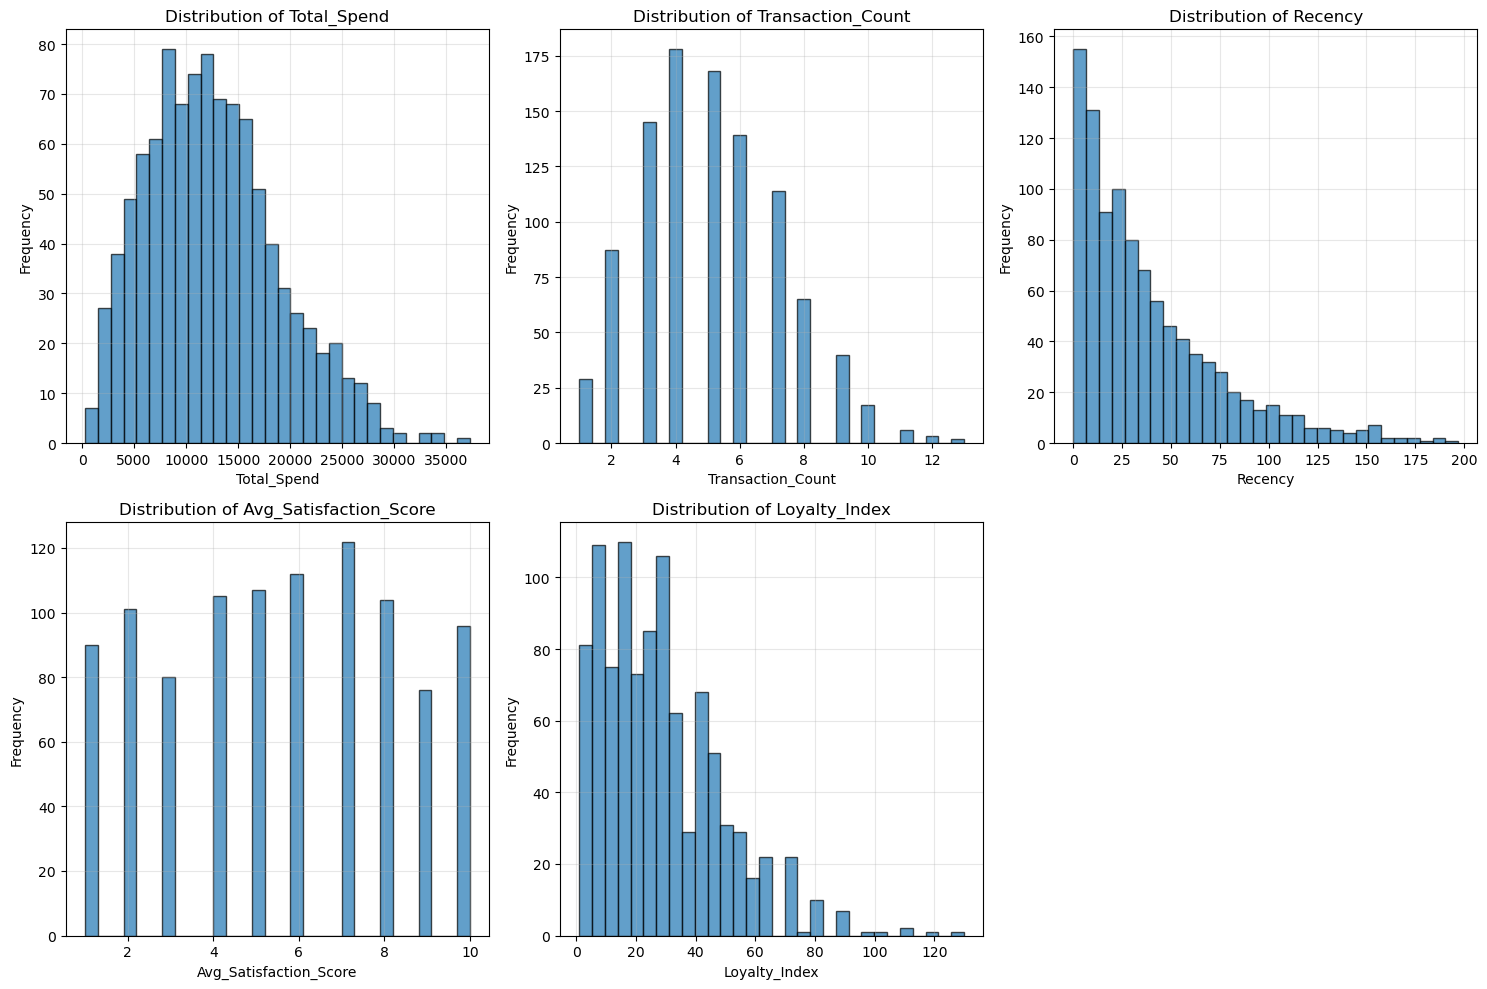

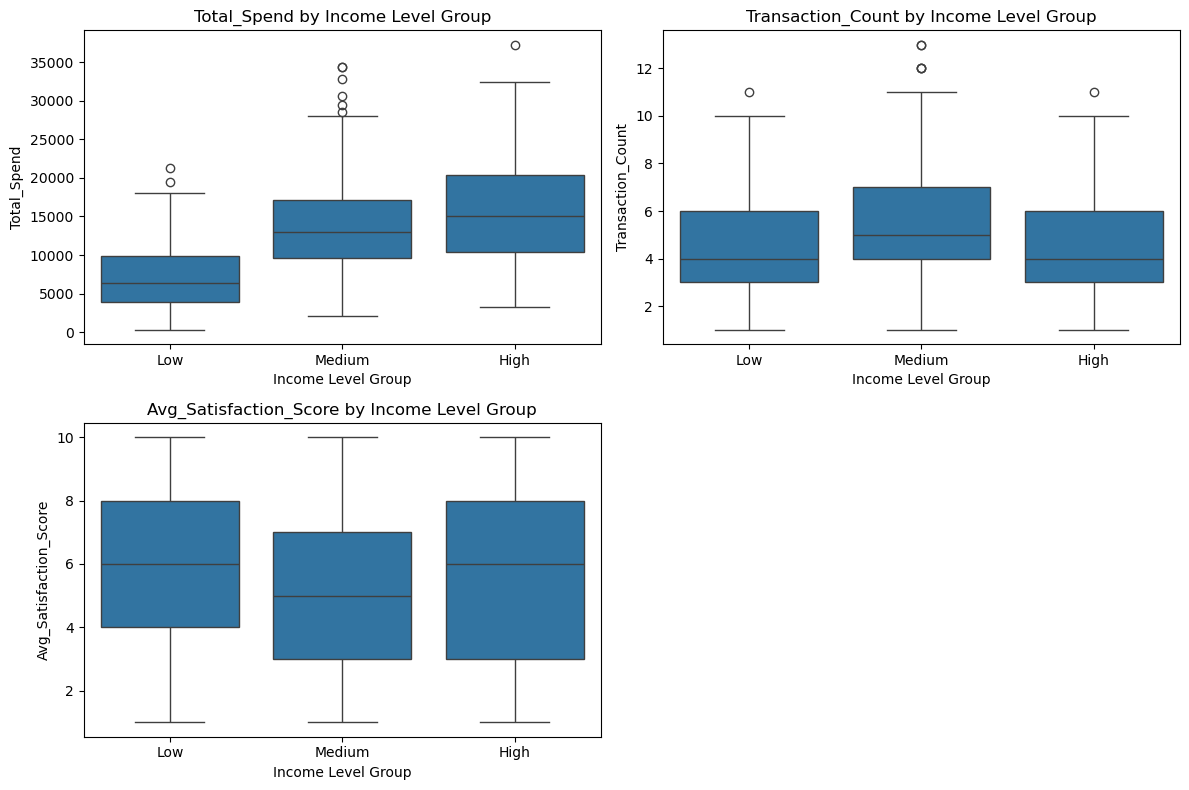

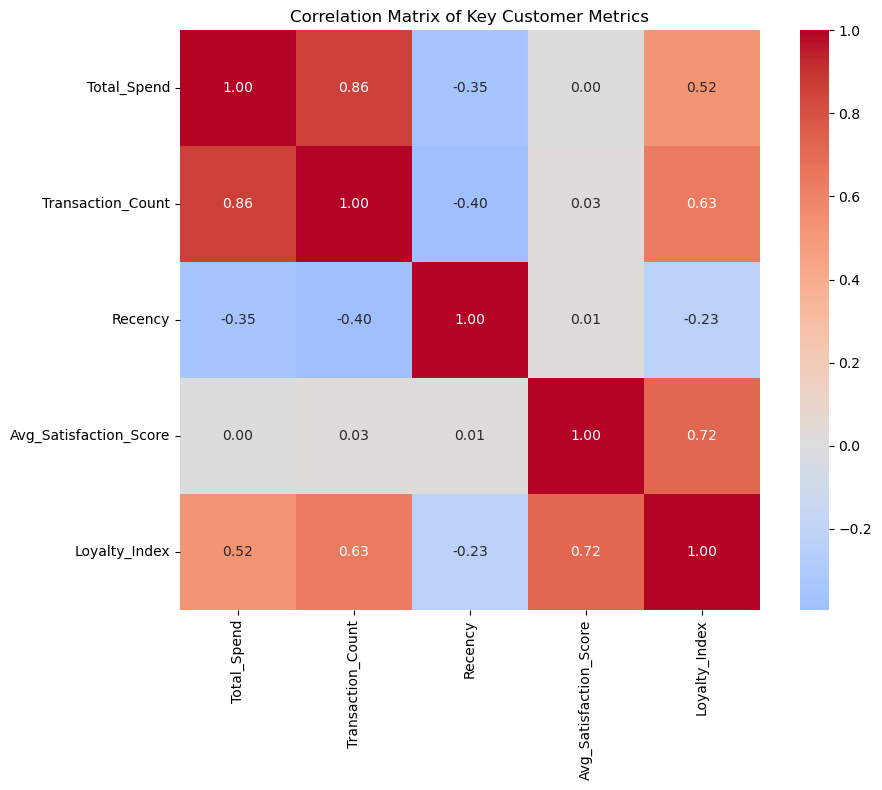

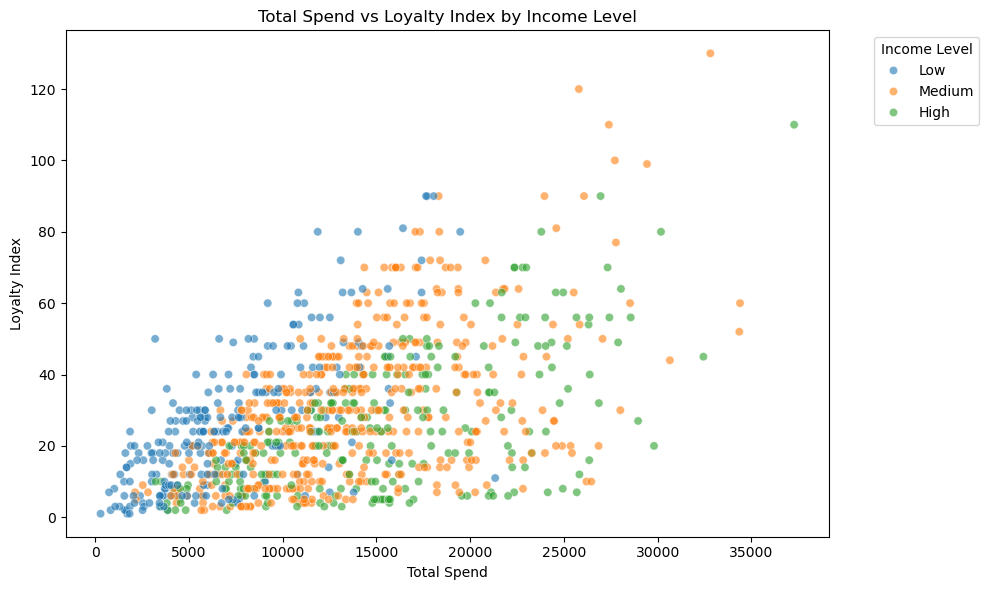


Key Observations from EDA:
- Total_Spend is right-skewed, indicating a small segment of high-value customers.
- Transaction_Count varies across customers, reflecting differing engagement levels.
- Recency highlights both active and inactive customer segments.
- Higher income groups generally exhibit higher spending and transaction volumes.
- Loyalty_Index shows a positive association with customer spending behavior.


In [7]:
# --- EXPLORATORY DATA ANALYSIS (EDA) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load engineered customer features
df = pd.read_csv('Engineered_Customer_Features.csv')

# Explicitly define categorical order for income levels
income_order = ['Low', 'Medium', 'High']
df['Income_Level_Group'] = pd.Categorical(
    df['Income_Level_Group'],
    categories=income_order,
    ordered=True
)

# Select key numerical features
key_features = [
    'Total_Spend',
    'Transaction_Count',
    'Recency',
    'Avg_Satisfaction_Score',
    'Loyalty_Index'
]

# --------------------------------------------------
# 1. Descriptive Statistics
# --------------------------------------------------
stats = df[key_features].describe().round(2)
print("Descriptive Statistics for Key Customer Metrics:")
print(stats)

# --------------------------------------------------
# 2. Distribution Analysis (Histograms)
# --------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    axes[i].hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 3. Boxplots by Income Level Group
# --------------------------------------------------
plt.figure(figsize=(12, 8))

for idx, feature in enumerate(['Total_Spend', 'Transaction_Count', 'Avg_Satisfaction_Score']):
    plt.subplot(2, 2, idx + 1)
    sns.boxplot(
        data=df,
        x='Income_Level_Group',
        y=feature,
        order=income_order
    )
    plt.title(f'{feature} by Income Level Group')
    plt.xlabel('Income Level Group')
    plt.ylabel(feature)

plt.tight_layout()
plt.savefig('eda_boxplots_income_level.png', dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 4. Correlation Heatmap
# --------------------------------------------------
plt.figure(figsize=(10, 8))
corr = df[key_features].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Matrix of Key Customer Metrics')

plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 5. Scatter Plot: Total Spend vs Loyalty Index
# --------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Total_Spend',
    y='Loyalty_Index',
    hue='Income_Level_Group',
    alpha=0.6
)
plt.title('Total Spend vs Loyalty Index by Income Level')
plt.xlabel('Total Spend')
plt.ylabel('Loyalty Index')
plt.legend(title='Income Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('eda_spend_vs_loyalty.png', dpi=300, bbox_inches='tight')
plt.show()


# --------------------------------------------------
# 6. Key Observations Summary
# --------------------------------------------------
print("\nKey Observations from EDA:")
print("- Total_Spend is right-skewed, indicating a small segment of high-value customers.")
print("- Transaction_Count varies across customers, reflecting differing engagement levels.")
print("- Recency highlights both active and inactive customer segments.")
print("- Higher income groups generally exhibit higher spending and transaction volumes.")
print("- Loyalty_Index shows a positive association with customer spending behavior.")
